In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from levels_utils import get_levels
from minigrid_levels_env import MiniGridLevelsEnv
from stable_baselines3.ppo import PPO

from minigrid.manual_control import ManualControl

c:\Code\ITHS\RL-Gaming\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
def get_level_env_frame(level_id: int) -> np.ndarray:
    """Get level environment frame."""
    env = MiniGridLevelsEnv(level_id=level_id)
    env.reset()

    return env.get_frame(highlight=False)

In [3]:
def display_all_levels(max_cols: int = 5) -> None:
    """Display all levels."""
    levels = get_levels()
    n_levels = len(levels)

    ncols = min(max_cols, n_levels)
    nrows = math.ceil(n_levels / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))

    axes = axes.flatten() if n_levels > 1 else [axes]

    for i, level_id in enumerate(levels):
        img = get_level_env_frame(level_id)

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Level {level_id}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
def display_single_level(level_id: int = 1) -> None:
    """Display single level."""
    img = get_level_env_frame(level_id)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Level {level_id}")

    plt.show()

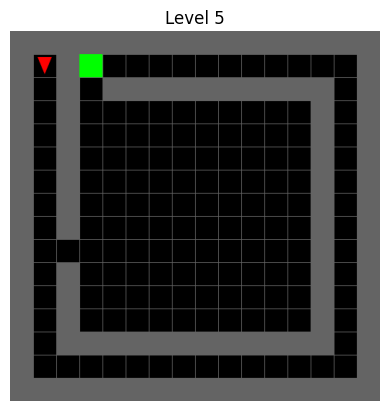

In [5]:
display_single_level(level_id=5)

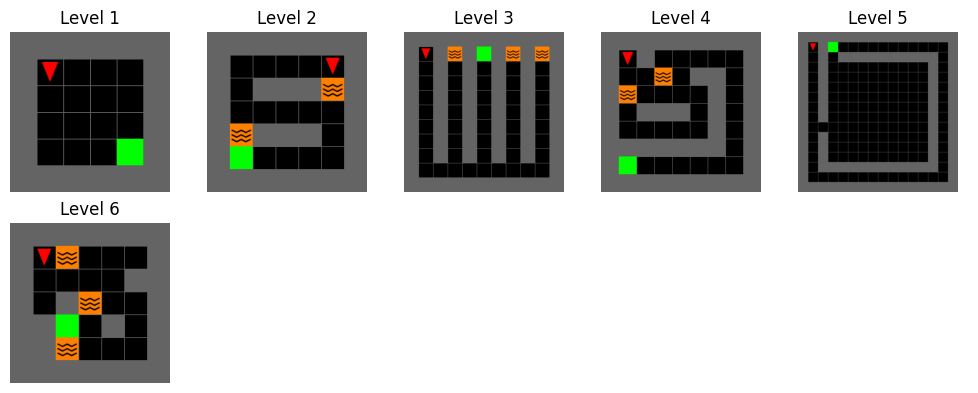

In [6]:
display_all_levels()

In [7]:
def human_test_level(level_id: int = 1) -> None:
    """Test the MiniGrid environment with manual control."""
    env = MiniGridLevelsEnv(render_mode="human", level_id=level_id)

    # Test level with manual control
    manual_control = ManualControl(env)
    manual_control.start()

In [ ]:
human_test_level(level_id=2)

In [ ]:
def test_model_on_level(model: PPO, level_id: int) -> None:
    """Test model on level."""